# Superstore Sales — Exploratory Data Analysis (EDA)

## Project Overview

This project performs Exploratory Data Analysis (EDA) on the Superstore Sales dataset.

The objective is to understand the structure and quality of the data, identify missing values and duplicates, examine distributions and relationships, analyze sales trends over time, and identify potential outliers.

The analysis follows a structured process of data inspection, data cleaning, exploratory analysis, and interpretation of key findings.

## 1. Importing Required Libraries

The following libraries are used for data manipulation, numerical analysis, and visualization.

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Loading Superstore Dataset for analysis

The CSV file is saved in a different text format than what pandas expects.  
By default, pandas tries to read files as **UTF‑8**,but the file is in another format (`latin1`).  

To fix it,we are telling pandas the right format when loading:

df = pd.read_csv("superstore_dataset.csv", encoding="latin1")

In [4]:
df = pd.read_csv("superstore_dataset.csv", encoding="latin1")

## 3.Initial Data Inspection

In [5]:
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


**Insights:**

The first few records were inspected to verify that the dataset was loaded correctly and that the columns contain the expected values.

In [6]:
df.tail()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.798
9796,9797,CA-2016-128608,12/1/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.368
9797,9798,CA-2016-128608,12/1/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.188
9798,9799,CA-2016-128608,12/1/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.376
9799,9800,CA-2016-128608,12/1/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-AC-10000487,Technology,Accessories,SanDisk Cruzer 4 GB USB Flash Drive,10.384


In [7]:
df.shape

(9800, 18)

**Insights:**

* The dataset contains 9,800 records and 18 columns, providing information about orders, customers, products, locations, dates, and sales.

In [8]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales'],
      dtype='object')

**Insights:**

* The dataset contains variables related to order information, customer details, geographical information, product categories, dates, and sales.

In [9]:
df.dtypes


Row_ID             int64
Order_ID          object
Order_Date        object
Ship_Date         object
Ship_Mode         object
Customer_ID       object
Customer_Name     object
Segment           object
Country           object
City              object
State             object
Postal_Code      float64
Region            object
Product_ID        object
Category          object
Sub_Category      object
Product_Name      object
Sales            float64
dtype: object

**Insights:**

The data types of the columns were inspected to identify variables that may require conversion or further preprocessing before analysis.

## `df.info()`


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

**Insights:**

* The dataset structure and non-null counts were examined to identify missing values and understand the data types of each variable.

## `df.describe()`


In [12]:
df.describe()

,Row_ID,Postal_Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


**Insights:**

* The descriptive statistics provide an overview of the numerical variables, including their central tendency, spread, minimum, and maximum values.

In [13]:
df.describe(include="object")

,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Region,Product_ID,Category,Sub_Category,Product_Name
count,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800
unique,4922,1230,1326,4,793,793,3,1,529,49,4,1861,3,17,1849
top,CA-2018-100111,5/9/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,34,5859,35,35,5101,9800,891,1946,3140,19,5909,1492,47


**Insights:**

* The categorical summary provides information about the number of unique categories and their most frequently occurring values.

## 4. Missing Value Analysis

Missing values can affect the accuracy of analysis. Therefore, the dataset is checked for missing values before performing further analysis.

In [14]:
df.isnull().sum()

Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64

In [15]:
(df.isnull().sum() / len(df)) * 100


Row_ID           0.000000
Order_ID         0.000000
Order_Date       0.000000
Ship_Date        0.000000
Ship_Mode        0.000000
Customer_ID      0.000000
Customer_Name    0.000000
Segment          0.000000
Country          0.000000
City             0.000000
State            0.000000
Postal_Code      0.112245
Region           0.000000
Product_ID       0.000000
Category         0.000000
Sub_Category     0.000000
Product_Name     0.000000
Sales            0.000000
dtype: float64

**Insight:**

* Most columns contain no missing values. The only missing values are present in the `Postal_Code` column, accounting for approximately 0.11% of the dataset.

In [16]:
df["Postal_Code"].isnull().sum()

np.int64(11)

In [17]:
# df[df["Postal_Code"].isnull()]

df.loc[df["Postal_Code"].isnull()]  # The only advantage is we can fetch columns using loc

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
2234,2235,CA-2018-104066,5/12/2018,10/12/2018,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03
5274,5275,CA-2016-162887,7/11/2016,9/11/2016,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20
8798,8799,US-2017-150140,6/4/2017,10/4/2017,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75
9146,9147,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98
9147,9148,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04
9148,9149,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29
9386,9387,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92
9387,9388,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28
9388,9389,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94
9389,9390,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04


### Handling Missing Values in `Postal_Code`

The missing values are found in records with the same location: **Burlington, Vermont**. By examining the dataset, the corresponding postal code for Burlington, Vermont is **5401**.

Therefore, i have filled missing `Postal_Code` values with **5401**.

In [18]:
df["Postal_Code"]=df["Postal_Code"].fillna(5401)

## 5. Duplicate Record Analysis

Duplicate records are checked to determine whether the dataset contains repeated observations.

In [19]:
df.duplicated().sum()

np.int64(0)

**Insight:**

* No completely duplicated records were found in the dataset. Therefore, no rows were removed based on duplicate records.

In [20]:
df.select_dtypes(include=np.number).columns

Index(['Row_ID', 'Postal_Code', 'Sales'], dtype='object')

In [21]:
df.select_dtypes(include=np.number).describe()

,Row_ID,Postal_Code,Sales
count,9800.000000,9800.000000,9800.000000
mean,4900.500000,55217.343265,230.769059
std,2829.160653,32066.750532,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,57551.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


**Insight:** 
* The numerical variables were identified and summarized to understand their ranges and distributions before performing further analysis.

In [22]:
df.select_dtypes(include="object").columns

Index(['Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID',
       'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Region',
       'Product_ID', 'Category', 'Sub_Category', 'Product_Name'],
      dtype='object')

**Include:**
* The categorical variables represent attributes such as shipping mode, customer segment, location, product category, and sub-category.

In [23]:
df["Sales"].min()

np.float64(0.444)

In [24]:
df["Sales"].max()

np.float64(22638.48)

## 6. Exploratory Data Analysis

The cleaned dataset is analyzed to identify distributions, patterns, relationships, trends, and potential anomalies.

### Univariate Analysis



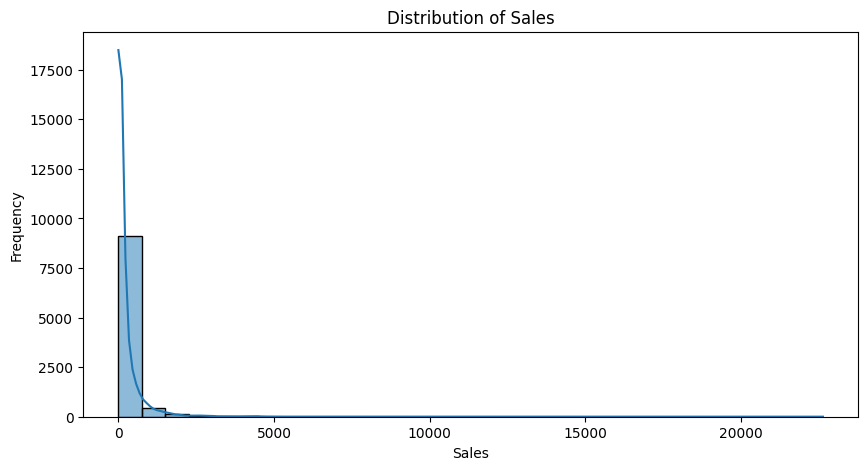

In [26]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x="Sales", bins=30, kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

**Insight:**

* Most sales values are concentrated on the lower end.

* The frequency drops sharply as Sales increases.

* There is a long tail toward the right, extending to very high sales values.

#### Categorical Distribution

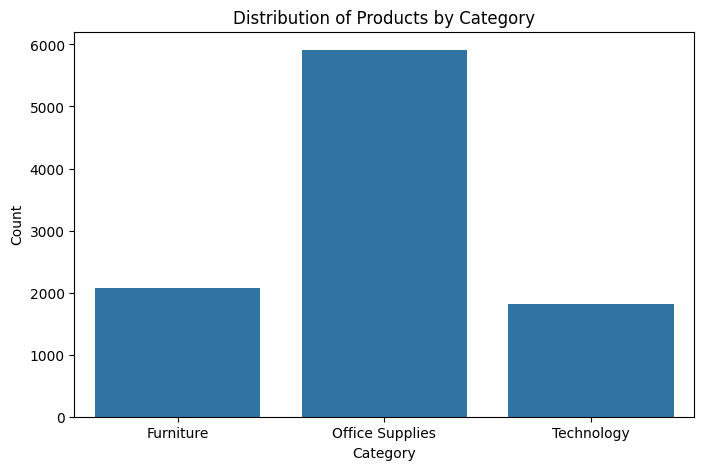

In [28]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Category")

plt.title("Distribution of Products by Category")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

**Insight:**

* Office Supplies has the highest number of records, around 5,900.
* Furniture has around 2,100 records.
* Technology has around 1,800 records.
* Therefore, the dataset contains considerably more Office Supplies records than the other two categories.

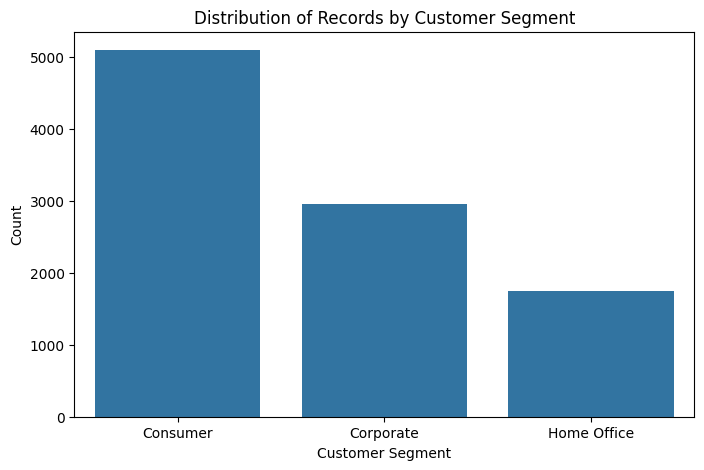

In [30]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Segment")

plt.title("Distribution of Records by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Count")

plt.show()

**Insight:**

* Consumer has the highest number of records, a little above 5,000.
* Corporate is the second-highest, around 3,000.
* Home Office has the fewest, around 1,750.

### Bivariate Analysis

In [33]:
category_sales = df.groupby("Category")["Sales"].sum()
category_sales

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64

Text(0, 0.5, 'Total Sales')

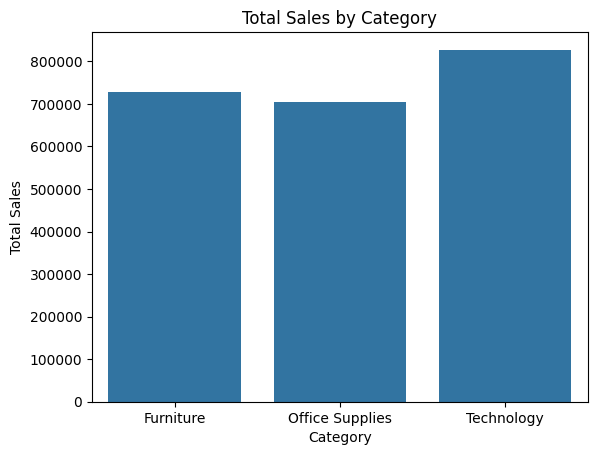

In [38]:
sns.barplot(x=category_sales.index,y=category_sales.values)
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")


**Insight:**

* Technology generates the highest total sales among the three categories, followed by Furniture and Office Supplies. Although Office Supplies has the highest number of records, it generates the lowest total sales among the three categories, indicating that a higher number of transactions does not necessarily result in higher total sales.

### Time-Based Sales Analysis

Sales are analyzed over time to identify changes and fluctuations in monthly sales performance.

In [40]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], dayfirst=True)

In [41]:
df["Order_Date"].dtype

dtype('<M8[ns]')

In [42]:
monthly_sales = df.groupby( df["Order_Date"].dt.to_period("M"))["Sales"].sum()

monthly_sales.head()

Order_Date
2015-01    14205.707
2015-02     4519.892
2015-03    55205.797
2015-04    27906.855
2015-05    23644.303
Freq: M, Name: Sales, dtype: float64

In [46]:
df["Month"] = df["Order_Date"].dt.to_period("M")
monthly_slaes=df.groupby("Month")["Sales"].sum()
monthly_sales.head()

Order_Date
2015-01    14205.707
2015-02     4519.892
2015-03    55205.797
2015-04    27906.855
2015-05    23644.303
Freq: M, Name: Sales, dtype: float64

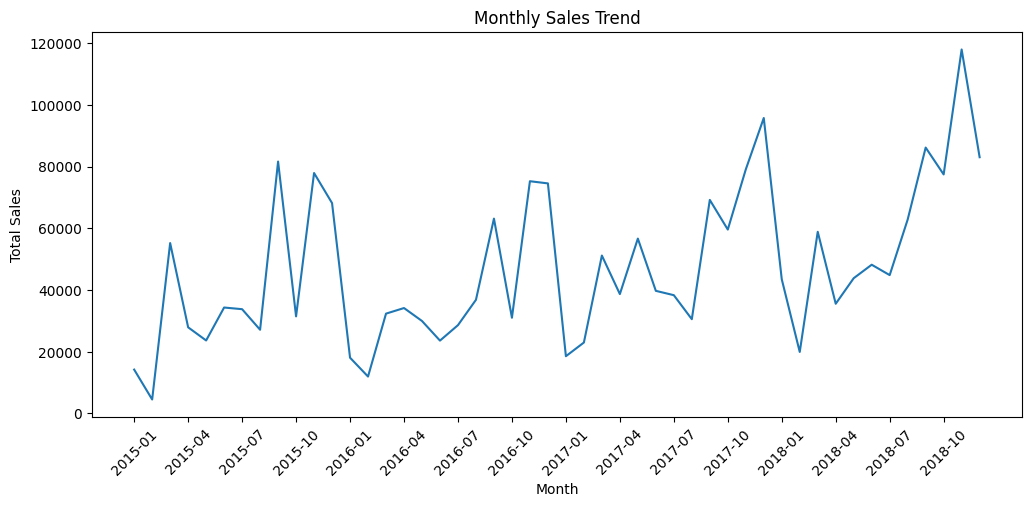

In [49]:
plt.figure(figsize=(12, 5))

sns.lineplot(x=monthly_sales.index.astype(str), y=monthly_sales.values)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(
    range(0, len(monthly_sales), 3),
    monthly_sales.index.astype(str)[::3],
    rotation=45
)

plt.show()


**Insight:**

* Monthly sales show substantial variation throughout the period, with several pronounced peaks and declines. Overall, the later part of the period contains some of the highest monthly sales values, indicating periods of stronger sales performance.

#### Monthly Sales Trend

The monthly sales trend is analyzed to identify changes and patterns in total sales over time. A line plot is used to visualize the variation in sales across different months.

##  Conclusion

The Exploratory Data Analysis provided an overall understanding of the Superstore dataset.

The analysis identified the structure and quality of the data, including missing values and duplicate records. The missing Postal_Code values were addressed using the corresponding location information.

The Sales distribution was found to be strongly right-skewed, indicating that most transactions have relatively lower sales values while a small number of transactions have much higher sales.

Category-level analysis showed that Technology generated the highest total sales, while Office Supplies had the highest number of records but the lowest total sales among the three categories.

Monthly analysis showed noticeable variations in sales over time, with several peaks and dips across the observed period.

Overall, the EDA helped identify important patterns, distributions, and potential anomalies in the Superstore dataset.